# Portable Alpha + Active Extension Reorientation Tutorial

This notebook is a compact reorientation guide for the repository owner. It assumes finance fluency and spends most of its effort on making the model math readable: what each symbol does, why the operations are shaped the way they are, and how the relationship moves when an input moves.

## 0. How to use this notebook

Run the cells top to bottom from the repository root. The code uses the public facade API:

```python
from pa_core.config import load_config
from pa_core.facade import run_single, RunOptions
```

The safest way to experiment is to tweak highlighted parameters such as `active_share`, `active_share_tc_decay`, `active_ext_cost_per_share`, `return_distribution`, `return_copula`, and `financing_mode`, then rerun from the setup cell downward. The notebook uses a fixed seed when comparing scenarios, so differences are the parameter effect rather than a new Monte Carlo draw.

In [1]:
import copy
import logging
import math
import os
import sys
import tempfile
import warnings
from pathlib import Path

start = Path.cwd().resolve()
for candidate in (start, *start.parents):
    if (candidate / "pa_core").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not find repository root containing pa_core/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# Keep matplotlib cache writes out of the home directory in sandboxed runs.
mpl_dir = Path(tempfile.gettempdir()) / "portable_alpha_tutorial_mpl"
mpl_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_dir))

warnings.filterwarnings("ignore", message="Pandas requires version.*")
logging.getLogger("pa_core.sim.financing").setLevel(logging.ERROR)
try:
    import ipykernel.kernelbase as _kernelbase

    async def _skip_child_process_scan(self):
        return None

    _kernelbase.Kernel._progressively_terminate_all_children = _skip_child_process_scan
except Exception:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from pa_core.config import load_config
from pa_core.facade import RunOptions, run_single

FIG_DIR = ROOT / "docs" / "tutorial" / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "Base": "#4b5563",
    "ExternalPA": "#2563eb",
    "ActiveExt": "#d97706",
    "InternalPA": "#059669",
    "InternalBeta": "#7c3aed",
    "Total": "#111827",
}

def fmt_pct(x, digits=2):
    return f"{x:.{digits}%}"

def savefig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

def load_yaml_dict(path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def run_from_dict(data, seed=42):
    cfg = load_config(copy.deepcopy(data))
    return run_single(cfg, idx, RunOptions(seed=seed))

In [2]:
cfg = load_config("config/params_template.yml")
idx = pd.read_csv("data/sp500tr_fred_divyield.csv")["Monthly_TR"].dropna()
art = run_single(cfg, idx, RunOptions(seed=42))

summ = art.summary.copy()
raw = art.raw_returns
display(summ[[
    "Agent",
    "terminal_AnnReturn",
    "terminal_ExcessReturn",
    "monthly_AnnVol",
    "monthly_CVaR",
    "monthly_TE",
    "terminal_ShortfallProb",
    "monthly_BreachProb",
]])

,Agent,terminal_AnnReturn,terminal_ExcessReturn,monthly_AnnVol,monthly_CVaR,monthly_TE,terminal_ShortfallProb,monthly_BreachProb
0,Base,0.075982,0.000000,0.079132,-0.041275,NaN,0.070,0.128917
1,ExternalPA,0.041200,-0.034782,0.052623,-0.028170,0.027064,0.049,0.063417
2,ActiveExt,0.022093,-0.053889,0.026317,-0.013940,0.052957,0.000,0.002167
3,InternalPA,0.020350,-0.055632,0.005021,-0.001335,0.078742,0.000,0.000000
4,InternalBeta,0.003200,-0.072782,0.004725,-0.002561,0.074418,0.000,0.000000
5,Total,0.089146,0.013164,0.084002,-0.043224,0.006040,0.066,0.134417


## 1. What this project is

This repository is a Monte Carlo tool for asking how a fund should combine benchmark beta, portable alpha, and active extension. It simulates monthly draws for the index, in-house alpha, external portable-alpha alpha, and active-extension alpha; maps those streams into contribution returns for each sleeve; and reports return, volatility, tail, tracking-error, shortfall, and breach metrics.

The sleeve picture is:

- `Base`: the benchmark reference sleeve, combining beta and in-house alpha according to `w_beta_H` and `w_alpha_H`.
- `ExternalPA`: outside alpha ported onto beta, sized by capital and `theta_extpa`.
- `ActiveExt`: active-extension alpha, sized by capital and `active_share`.
- `InternalPA`: in-house alpha, optionally net of internal-PA financing.
- `InternalBeta`: margin/beta backing sleeve.
- `Total`: the sum of overlay sleeves excluding `Base`; a Base-only run therefore has `Total = 0`.

The code surface is intentionally split. `pa_core/` contains the engine: simulation draws in `sim/`, sleeve formulas in `agents/`, metrics and export logic in `reporting/`, and charts in `viz/`. `dashboard/` is the Streamlit experience, including the scenario wizard, results page, scenario grid, stress lab, and run logs. The `pa` CLI runs scenarios and sweeps from YAML for repeatable workflows.

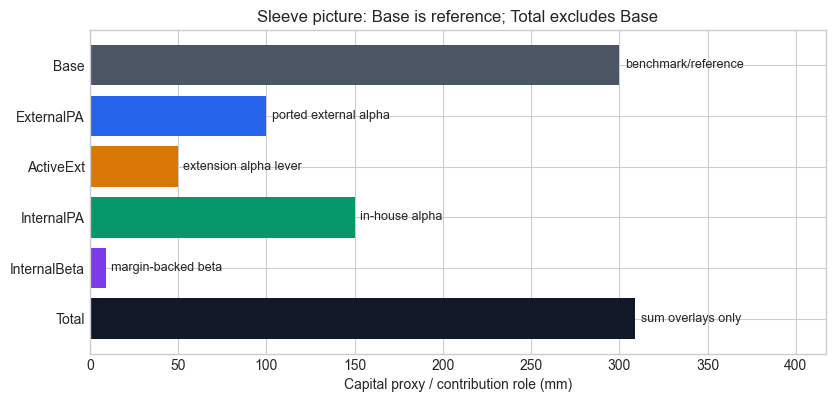

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_sleeve_picture.png')

In [3]:
from pa_core.validators import calculate_margin_requirement

agent_caps = {agent.name: agent.capital for agent in cfg.agents}
agent_caps["InternalBeta"] = calculate_margin_requirement(
    cfg.reference_sigma,
    cfg.volatility_multiple,
    cfg.total_fund_capital,
    financing_model=cfg.financing_model,
    schedule_path=cfg.financing_schedule_path,
    term_months=cfg.financing_term_months,
)
sleeves = ["Base", "ExternalPA", "ActiveExt", "InternalPA", "InternalBeta", "Total"]
roles = {
    "Base": "benchmark/reference",
    "ExternalPA": "ported external alpha",
    "ActiveExt": "extension alpha lever",
    "InternalPA": "in-house alpha",
    "InternalBeta": "margin-backed beta",
    "Total": "sum overlays only",
}
widths = [agent_caps.get(name, cfg.total_fund_capital if name == "Base" else 0.0) for name in sleeves]
widths[-1] = sum(agent_caps.get(name, 0.0) for name in ["ExternalPA", "ActiveExt", "InternalPA", "InternalBeta"])

fig, ax = plt.subplots(figsize=(9.5, 4.2))
y = np.arange(len(sleeves))
ax.barh(y, widths, color=[COLORS.get(name, "#6b7280") for name in sleeves])
ax.set_yticks(y, sleeves)
ax.invert_yaxis()
ax.set_xlabel("Capital proxy / contribution role (mm)")
ax.set_title("Sleeve picture: Base is reference; Total excludes Base")
for i, (name, width) in enumerate(zip(sleeves, widths)):
    ax.text(max(width, 1) + 3, i, roles[name], va="center", fontsize=9)
ax.set_xlim(0, max(widths) * 1.35)
savefig(fig, "fig_sleeve_picture.png")

## 2. The finance idea

Portable alpha separates two jobs that are often bundled together: beta exposure and manager skill. The beta sleeve keeps the desired market exposure. The alpha sleeve tries to add excess return that is not just a disguised index bet. "Porting" alpha means financing or overlaying the alpha stream onto the beta exposure so the fund does not have to choose between market exposure and manager skill.

Active extension, such as a 130/30 structure, relaxes the long-only constraint. The manager can short lower-conviction names and redeploy proceeds into higher-conviction longs. That can raise the amount of active skill that gets into the portfolio, but it also brings financing, borrow, leverage, and capacity questions. This repo's current transfer-coefficient feature makes that tradeoff explicit: bigger active share can add alpha, but each extra unit may capture less skill than the last.

## 3. The math, taught so you can read it

### 3a. Sleeve return decomposition

Plain-English idea: each sleeve emits a fund-level contribution return. The capital share scales the sleeve before it reaches the total portfolio. That is why the same alpha stream means different things for a $50mm sleeve and a $100mm sleeve inside a $300mm fund.

**The equation**

With capital weight \(w = \text{sleeve capital}/\text{total capital}\):

\[
r_{\text{ExternalPA},t}=w(r_{\beta,t}-f_t)+(w\theta)r_{M,t}
\]

\[
r_{\text{ActiveExt},t}=w(r_{\beta,t}-f_t)+(ws)r_{E,t}
\]

\[
r_{\text{InternalPA},t}=a\,r_{H,t}-f_{\text{ipa},t}
\]

\[
r_{\text{Base},t}=w_\beta(r_{\beta,t}-f_t)+w_\alpha r_{H,t}
\]

\[
r_{\text{Total},t}=\sum_{\text{overlay sleeves}}r_{i,t}\quad\text{excluding Base.}
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(r_{\beta,t}\) | monthly benchmark beta return | monthly return |
| \(r_H, r_E, r_M\) | in-house, active-extension, and external-PA alpha streams | monthly return |
| \(f_t\) | financing spread for beta/overlay sleeve | monthly return cost |
| \(f_{\text{ipa},t}\) | internal-PA financing cost | monthly return cost |
| \(w\) | sleeve capital divided by total fund capital | unitless |
| \(a\) | internal-PA capital share | unitless |
| \(\theta\) | external-PA alpha fraction | unitless |
| \(s\) | active share / active-extension lever | unitless |
| \(w_\beta,w_\alpha\) | benchmark beta and alpha weights in Base | unitless |

**How the symbols work together (the idea)**

The structural move is multiplication by a capital share before aggregation. \(w(r_\beta-f)\) says the beta financing result only contributes in proportion to capital assigned to that sleeve. \((w\theta)r_M\) and \((ws)r_E\) add a second scaling layer: first the sleeve size, then the alpha lever inside that sleeve. `InternalPA` uses \(a r_H\) because its capital share is itself the scale on in-house alpha, then subtracts its own financing. `Base` is different: it is the benchmark comparator, not part of `Total`.

Behavior to notice: doubling \(w\) doubles the contribution return, all else equal. Setting \(s=0\) removes active-extension alpha but leaves the sleeve's beta financing term. Setting all overlay sleeve capital to zero leaves `Total = 0`, because `Base` is deliberately excluded from total overlay contribution.

ExternalPA worked contribution: 0.3667%


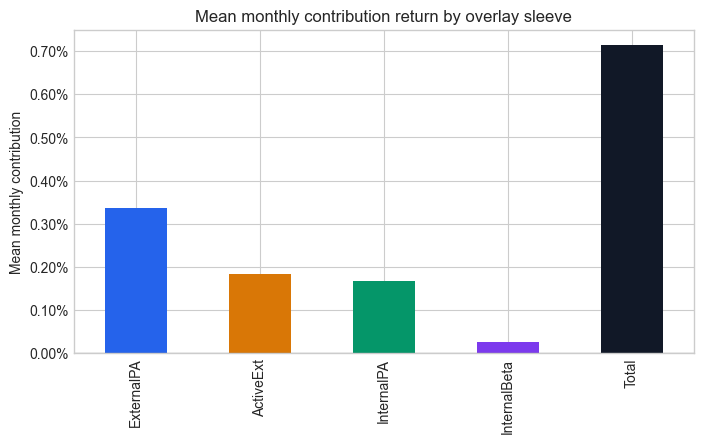

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3a_sleeve_contributions.png')

In [4]:
w = 100 / 300
theta = 0.50
r_beta, f, r_M = 0.010, 0.001, 0.004
external_pa_contribution = w * (r_beta - f) + (w * theta) * r_M
print(f"ExternalPA worked contribution: {external_pa_contribution:.4%}")

mean_monthly = pd.Series({name: df.to_numpy().mean() for name, df in raw.items() if name != "Base"})
fig, ax = plt.subplots(figsize=(8, 4.2))
mean_monthly.plot(kind="bar", ax=ax, color=[COLORS.get(i, "#6b7280") for i in mean_monthly.index])
ax.set_title("Mean monthly contribution return by overlay sleeve")
ax.set_ylabel("Mean monthly contribution")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
ax.axhline(0, color="#111827", linewidth=0.8)
savefig(fig, "fig_3a_sleeve_contributions.png")

**Comprehension Q**

1. Which terms vanish when `active_share = 0`, and what remains in `ActiveExt`?

<details><summary>Answer</summary>
The \((ws)r_E\) alpha term vanishes. The sleeve can still have \(w(r_\beta-f)\), so it may retain beta-financing contribution even with no active-extension alpha.
</details>

2. Why is `Base` excluded from `Total`?

<details><summary>Answer</summary>
`Base` is the benchmark comparator. `Total` is the sum of overlay contribution sleeves, so including `Base` would double count the benchmark and change the interpretation from overlay contribution to full benchmark-plus-overlay portfolio.
</details>

### 3b. Annual-to-monthly conversion

Plain-English idea: the engine normalizes configured alpha means and volatilities to monthly units before simulation. The default mean conversion is simple division by 12; volatility divides by \(\sqrt{12}\) because variance, not standard deviation, scales linearly with time.

**The equation**

\[
\mu_m=\frac{\mu_a}{12},\qquad
\mu_{m,\text{geo}}=(1+\mu_a)^{1/12}-1,\qquad
\sigma_m=\frac{\sigma_a}{\sqrt{12}},\qquad
\Sigma_m=\frac{\Sigma_a}{12}.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(\mu_a,\mu_m\) | annual and monthly expected return | return per year/month |
| \(\mu_{m,\text{geo}}\) | geometric monthly equivalent | monthly return |
| \(\sigma_a,\sigma_m\) | annual and monthly volatility | std dev per year/month |
| \(\Sigma_a,\Sigma_m\) | annual and monthly covariance matrix | variance/covariance |

**How the symbols work together (the idea)**

The mean equation is a budgeting convention: the annual expected return is spread evenly across 12 monthly buckets. The geometric alternative uses an exponent because compounding needs the same return repeated 12 times to rebuild the annual return. Volatility is different because independent variances add over time; if annual variance is 12 monthly variances, standard deviation must divide by \(\sqrt{12}\). Covariance divides by 12 for the same variance-addition reason.

Behavior to notice: doubling \(\mu_a\) doubles simple \(\mu_m\). Doubling \(\sigma_a\) doubles \(\sigma_m\), but changing the horizon from 12 to 48 months would scale standard deviation with a square root, not linearly. For small means, simple and geometric monthly means are close; at higher annual means the geometric version is lower because it allows compounding to do part of the work.

12% annual mean -> simple monthly 1.0000%; geometric monthly 0.9489%
18% annual vol -> monthly vol 5.1962%


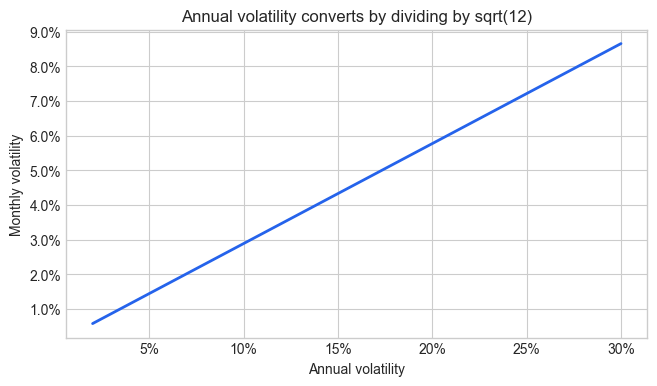

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3b_unit_conversion.png')

In [5]:
mu_a = 0.12
sigma_a = 0.18
mu_m_simple = mu_a / 12
mu_m_geo = (1 + mu_a) ** (1 / 12) - 1
sigma_m = sigma_a / math.sqrt(12)
print(f"12% annual mean -> simple monthly {mu_m_simple:.4%}; geometric monthly {mu_m_geo:.4%}")
print(f"18% annual vol -> monthly vol {sigma_m:.4%}")

annual_vols = np.linspace(0.02, 0.30, 50)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(annual_vols, annual_vols / np.sqrt(12), color="#2563eb", linewidth=2)
ax.set_title("Annual volatility converts by dividing by sqrt(12)")
ax.set_xlabel("Annual volatility")
ax.set_ylabel("Monthly volatility")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
savefig(fig, "fig_3b_unit_conversion.png")

**Comprehension Q**

1. Why is covariance divided by 12 rather than by \(\sqrt{12}\)?

<details><summary>Answer</summary>
Covariance is a second-moment quantity like variance. Variance/covariance adds across independent periods, while standard deviation is the square root of variance.
</details>

2. When would the geometric monthly mean matter more?

<details><summary>Answer</summary>
When annual means are large or compounding precision matters. The geometric monthly rate is the rate that compounds back to the annual return; the simple default is a linear approximation.
</details>

### 3c. Joint return draws: marginals and copulas

Plain-English idea: the model draws index and alpha streams together, not one at a time, so correlation and tail assumptions matter. A marginal distribution controls each stream's one-dimensional shape. A copula controls how streams co-move, especially in the tails.

**The equation**

\[
r \sim \mathcal{N}(\mu,\Sigma)
\]

For a Student-t marginal with finite variance:

\[
r_i=\mu_i+\sigma_i z_i\sqrt{\frac{df-2}{df}}\bigg/\sqrt{\frac{u_i}{df}},
\qquad u_i\sim\chi^2_{df}.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(r\) | vector of monthly returns for index, H, E, M | monthly returns |
| \(\mu\) | vector of monthly means | monthly returns |
| \(\Sigma\) | monthly covariance matrix | return covariance |
| \(z_i\) | standard normal shock with configured correlation | unitless |
| \(df\) | Student-t degrees of freedom | unitless |
| \(u_i\) | chi-square draw controlling tail thickness | unitless |
| \(\sqrt{(df-2)/df}\) | variance-preserving Student-t scale | unitless |

**How the symbols work together (the idea)**

The normal draw uses \(\Sigma\) as a joint shape: variances set each stream's width, covariances tilt the cloud. The Student-t formula keeps the same center and target variance but divides by a random denominator. When \(u_i\) is small, the denominator is small and the return shock becomes large; that is the tail mechanism. The scale \(\sqrt{(df-2)/df}\) offsets the naturally larger Student-t variance so the configured \(\sigma_i\) still means what the user entered.

Behavior to notice: as \(df\to\infty\), the Student-t denominator stabilizes and the marginal approaches normal. Lower \(df\) means more tail mass. With a Gaussian copula, each marginal can be fat-tailed but extreme co-movement is weaker; with a t-copula, a common tail denominator makes bad months more likely to arrive together.

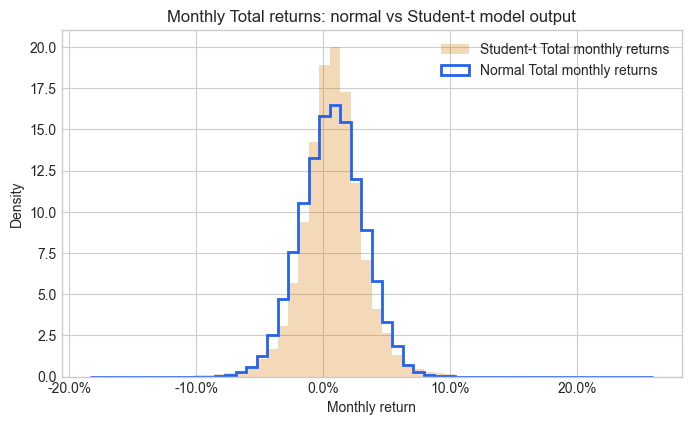

Normal 1% quantile: -4.97%
Student-t 1% quantile: -5.45%


In [6]:
base_data = load_yaml_dict("config/params_template.yml")
per_path_data = copy.deepcopy(base_data)
per_path_data["financing_mode"] = "per_path"

normal_art = run_from_dict(per_path_data, seed=42)
student_data = copy.deepcopy(per_path_data)
student_data.update({"return_distribution": "student_t", "return_copula": "t", "return_t_df": 5.0})
student_art = run_from_dict(student_data, seed=42)

normal_total = normal_art.raw_returns["Total"].to_numpy().reshape(-1)
student_total = student_art.raw_returns["Total"].to_numpy().reshape(-1)

bins = np.linspace(
    min(normal_total.min(), student_total.min()),
    max(normal_total.max(), student_total.max()),
    55,
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(student_total, bins=bins, density=True, alpha=0.28, color="#d97706", label="Student-t Total monthly returns")
ax.hist(normal_total, bins=bins, density=True, histtype="step", linewidth=2.0, color="#2563eb", label="Normal Total monthly returns")
ax.set_title("Monthly Total returns: normal vs Student-t model output")
ax.set_xlabel("Monthly return")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.legend(frameon=False)
savefig(fig, "fig_total_return_hist.png")

print(f"Normal 1% quantile: {np.quantile(normal_total, 0.01):.2%}")
print(f"Student-t 1% quantile: {np.quantile(student_total, 0.01):.2%}")

**Comprehension Q**

1. Which part of the Student-t formula creates fat tails?

<details><summary>Answer</summary>
The random chi-square denominator. Small denominator draws magnify the normal shock, creating more extreme outcomes than a normal distribution with the same variance.
</details>

2. What changes when the copula is t rather than Gaussian?

<details><summary>Answer</summary>
The marginal tail shape can be the same, but the t-copula adds stronger tail dependence: extreme moves across streams are more likely to occur together.
</details>

### 3d. Covariance build and repair

Plain-English idea: users think in volatilities and correlations, but simulation needs a covariance matrix. The engine builds covariance from those inputs, then repairs non-PSD matrices so the draw is mathematically possible.

**The equation**

\[
\Sigma=(\sigma\sigma^\top)\circ C
\]

\[
\hat{\Sigma}=(1-\delta)S+\delta T
\]

Nearest-PSD repair clips negative eigenvalues:

\[
\lambda_i^- < 0 \quad\Rightarrow\quad \lambda_i^{\text{repaired}}=0.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(\sigma\) | vector of monthly standard deviations | monthly volatility |
| \(C\) | correlation matrix | unitless |
| \(\circ\) | elementwise multiplication | operation |
| \(S\) | sample/input covariance matrix | covariance |
| \(T\) | shrinkage target, typically a structured safer matrix | covariance |
| \(\delta\) | Ledoit-Wolf shrinkage intensity | unitless, 0 to 1 |
| \(\lambda_i\) | eigenvalues of covariance matrix | variance units |

**How the symbols work together (the idea)**

The outer product \(\sigma\sigma^\top\) creates every possible pair of volatilities. Elementwise multiplication by \(C\) then keeps each pair's covariance proportional to its correlation. This is why covariance is not "vol plus corr" as a sum: correlation must scale the product of the two standard deviations. Shrinkage is a weighted average between the noisy matrix \(S\) and target \(T\); \(\delta=0\) trusts the input, while \(\delta=1\) fully replaces it with the target.

Behavior to notice: if a correlation rises, only the matching off-diagonal covariance rises. If a volatility doubles, every covariance involving that asset doubles, and its own variance quadruples. Negative eigenvalues mean the matrix implies impossible variance for some portfolio; clipping them removes that impossible direction.

Eigenvalues before repair: [-0.00070701  0.00112194  0.00248507]
Eigenvalues after repair:  [0.         0.00112194 0.00248507]


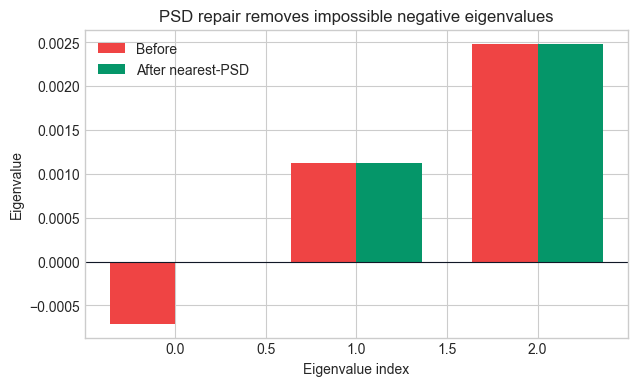

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3d_psd_repair.png')

In [7]:
from pa_core.sim.covariance import nearest_psd

bad_corr = np.array([
    [1.0, 0.95, 0.95],
    [0.95, 1.0, -0.95],
    [0.95, -0.95, 1.0],
])
sigma = np.array([0.04, 0.03, 0.02])
bad_cov = np.outer(sigma, sigma) * bad_corr
repaired_cov = nearest_psd(bad_cov)

before = np.linalg.eigvalsh(bad_cov)
after = np.linalg.eigvalsh(repaired_cov)
print("Eigenvalues before repair:", np.round(before, 8))
print("Eigenvalues after repair: ", np.round(after, 8))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(before))
ax.bar(x - 0.18, before, width=0.36, label="Before", color="#ef4444")
ax.bar(x + 0.18, after, width=0.36, label="After nearest-PSD", color="#059669")
ax.axhline(0, color="#111827", linewidth=0.8)
ax.set_title("PSD repair removes impossible negative eigenvalues")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Eigenvalue")
ax.legend(frameon=False)
savefig(fig, "fig_3d_psd_repair.png")

**Comprehension Q**

1. Why does covariance use an outer product of volatilities?

<details><summary>Answer</summary>
Covariance between two streams is correlation times both streams' standard deviations. The outer product creates every pairwise volatility product so the correlation matrix can scale each pair.
</details>

2. What does \(\delta=1\) mean in shrinkage?

<details><summary>Answer</summary>
The estimate fully moves to the target \(T\). The input/sample covariance \(S\) receives zero weight.
</details>

### 3e. Tracking error

Plain-English idea: tracking error is the volatility of active return. In this repo, the metric pools every simulated path and month into one distribution before annualizing.

**The equation**

\[
\mathrm{TE}=\operatorname{std}(r-r_{\text{bench}})\sqrt{12}.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(r\) | strategy monthly contribution return | monthly return |
| \(r_{\text{bench}}\) | benchmark/Base monthly return | monthly return |
| \(\operatorname{std}\) | sample standard deviation over path-month draws | monthly volatility |
| \(\sqrt{12}\) | annualization factor for volatility | square-root time |

**How the symbols work together (the idea)**

The subtraction creates active return: the part that differs from the benchmark. The standard deviation asks how unstable that active difference is. Multiplication by \(\sqrt{12}\) converts monthly active volatility to annualized active volatility. The audit nuance is the axis: the code flattens all path-by-month differences before taking the standard deviation. A per-path TE would calculate one TE per simulated path and then average those values.

Behavior to notice: if a strategy exactly equals the benchmark every month, the difference is zero and TE is zero. If active returns are scaled by 2, TE scales by 2. Pooling path-month draws can differ from per-path averaging because cross-path dispersion and time dispersion are not summarized in the same order.

Pooled TE used by summary: 0.604%
Average per-path TE:        0.589%
Relative difference:        2.49%


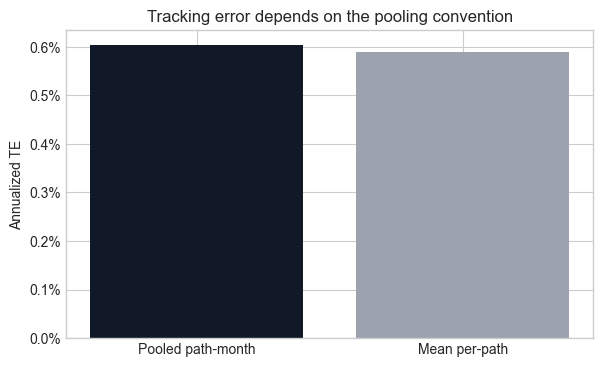

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3e_tracking_error.png')

In [8]:
total = raw["Total"].to_numpy()
base = raw["Base"].to_numpy()
diff = total - base
pooled_te = diff.reshape(-1).std(ddof=1) * np.sqrt(12)
per_path_te = diff.std(axis=1, ddof=1) * np.sqrt(12)
print(f"Pooled TE used by summary: {pooled_te:.3%}")
print(f"Average per-path TE:        {per_path_te.mean():.3%}")
print(f"Relative difference:        {(pooled_te / per_path_te.mean() - 1):.2%}")

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.bar(["Pooled path-month", "Mean per-path"], [pooled_te, per_path_te.mean()], color=["#111827", "#9ca3af"])
ax.set_title("Tracking error depends on the pooling convention")
ax.set_ylabel("Annualized TE")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
savefig(fig, "fig_3e_tracking_error.png")

**Comprehension Q**

1. Which operation makes TE an active-risk metric rather than a total-risk metric?

<details><summary>Answer</summary>
The subtraction \(r-r_{\text{bench}}\). It removes the benchmark component and measures the volatility of the difference.
</details>

2. Why can pooled TE differ from average per-path TE?

<details><summary>Answer</summary>
Pooled TE takes one standard deviation over every path-month draw at once. Per-path TE first summarizes time variation within each path and then averages; those operations need not match.
</details>

### 3f. VaR, CVaR, shortfall, and breach

Plain-English idea: the model distinguishes monthly loss/tail metrics from terminal-horizon shortfall metrics. That distinction matters because monthly pain and horizon failure are different questions.

**The equation**

\[
\mathrm{VaR}_\alpha=-Q_{1-\alpha}(r)
\]

\[
\mathrm{CVaR}=\mathbb{E}[r\mid r\le \text{cutoff}]
\]

\[
\Pr\left(\prod_t(1+r_t)-1<\theta\right)
\]

\[
\Pr(r_t<\theta).
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(\alpha\) | confidence level, usually 95% | unitless |
| \(Q_{1-\alpha}(r)\) | lower-tail return quantile | monthly return |
| \(\mathrm{VaR}_\alpha\) | positive loss convention for lower-tail loss | monthly loss |
| \(\mathrm{CVaR}\) | average return in the tail beyond the cutoff | monthly return |
| \(r_t\) | monthly return at month \(t\) | monthly return |
| \(\theta\) | threshold: annualized for terminal shortfall, monthly for breach | return |

**How the symbols work together (the idea)**

The quantile \(Q\) chooses the boundary of the bad tail. The negative sign in positive-loss VaR flips a bad negative return into a positive loss number. CVaR then averages the returns beyond that boundary, so it asks how bad the bad months are, not just where the boundary sits. The product \(\prod_t(1+r_t)-1\) compounds a full path before comparing it with a horizon threshold; monthly breach skips compounding and counts individual months below a monthly threshold. Precisely, the code compares the compounded path return to the annual hurdle compounded to the horizon, \((1+\theta)^{N/12}-1\); at a 12-month horizon that equals \(\theta\), which is why the simple form above is exact for the bundled one-year runs.

Behavior to notice: raising confidence from 95% to 99% moves VaR deeper into the tail. More simulations reduce sampling noise but do not remove model error. The repo summary's `monthly_VaR` column stores the signed lower return quantile; use `-monthly_VaR` when presenting positive-loss VaR.

Total signed monthly VaR cutoff: -3.34%; positive-loss VaR: 3.34%
Total monthly CVaR tail mean:    -4.32%
Terminal shortfall probability:  6.60%
Monthly breach probability:      13.44%


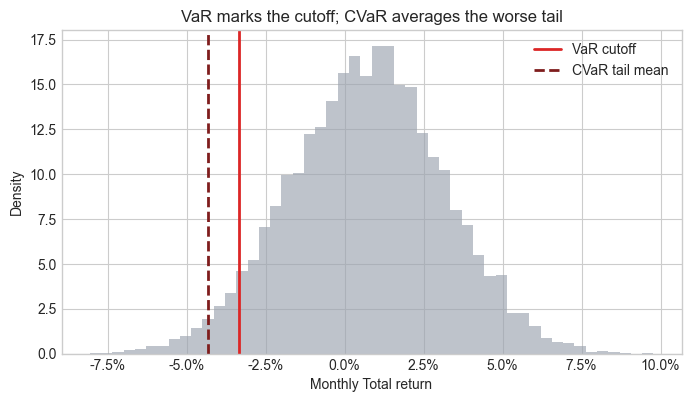

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3f_var_cvar.png')

In [9]:
total_flat = total.reshape(-1)
total_row = summ.loc[summ["Agent"] == "Total"].iloc[0]
signed_var = total_row["monthly_VaR"]
cvar = total_row["monthly_CVaR"]
print(f"Total signed monthly VaR cutoff: {signed_var:.2%}; positive-loss VaR: {-signed_var:.2%}")
print(f"Total monthly CVaR tail mean:    {cvar:.2%}")
print(f"Terminal shortfall probability:  {total_row['terminal_ShortfallProb']:.2%}")
print(f"Monthly breach probability:      {total_row['monthly_BreachProb']:.2%}")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(total_flat, bins=50, color="#9ca3af", alpha=0.65, density=True)
ax.axvline(signed_var, color="#dc2626", linewidth=2, label="VaR cutoff")
ax.axvline(cvar, color="#7f1d1d", linewidth=2, linestyle="--", label="CVaR tail mean")
ax.set_title("VaR marks the cutoff; CVaR averages the worse tail")
ax.set_xlabel("Monthly Total return")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.legend(frameon=False)
savefig(fig, "fig_3f_var_cvar.png")

**Comprehension Q**

1. Why does positive-loss VaR have a minus sign?

<details><summary>Answer</summary>
The lower return quantile is usually negative. Multiplying by -1 reports the loss as a positive number.
</details>

2. Why is terminal shortfall not the same as monthly breach probability?

<details><summary>Answer</summary>
Terminal shortfall compounds the full path and compares the ending return with a horizon threshold. Monthly breach counts individual months below a monthly threshold, regardless of the final compounded outcome.
</details>

### 3g. The transfer coefficient: how much active extension is enough

Plain-English idea: active extension should not be a purely linear alpha dial. Relaxing constraints may transfer more skill into the portfolio, but the marginal transfer can decay as the active bet grows.

**The equation**

\[
\mathrm{TC}(s)=\frac{1}{1+\kappa s},\qquad
\alpha_{\text{gross}}(s)=\frac{s\mu}{1+\kappa s},\qquad
s^\star=\frac{\sqrt{\mu/c}-1}{\kappa}.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(s\) | active share / extension lever | unitless, usually 0 to 1 |
| \(\kappa\) | alpha decay rate; 0 means no diminishing returns | unitless |
| \(\mu\) | sleeve's monthly alpha mean | monthly return |
| \(c\) | monthly extension cost per unit of \(s\) | fraction of NAV |
| \(\mathrm{TC}\) | transfer coefficient, fraction of ideal alpha captured | unitless, \(0<\mathrm{TC}\le1\) |
| \(\alpha_{\text{gross}}\) | expected monthly alpha contribution before cost | monthly return |
| \(s^\star\) | active share that maximizes net alpha | unitless |

**How the symbols work together (the idea)**

\(\mathrm{TC}(s)\) is a ratio whose denominator grows with \(s\), so it starts at 1 for a tiny bet and shrinks as the bet grows. \(\kappa\) sets how fast the denominator grows. The structural move that matters is multiplying the linear alpha \(s\mu\) by this shrinking ratio; that bends a straight line into a curve that still rises but flattens. In \(s^\star\), \(\sqrt{\mu/c}\) is the alpha-versus-cost tradeoff and division by \(\kappa\) scales the optimum by how quickly skill decays.

Behavior to notice: larger \(\kappa\) means faster decay and a smaller optimum. If \(\kappa=0\), the denominator becomes 1, the curve no longer bends, and the old "more is always better" linear model returns. If cost \(c\) rises, the optimum falls because each unit of extension has a higher hurdle.

Closed-form s*: 0.62


Model-output peak in grid: active_share=0.60, return=3.936%


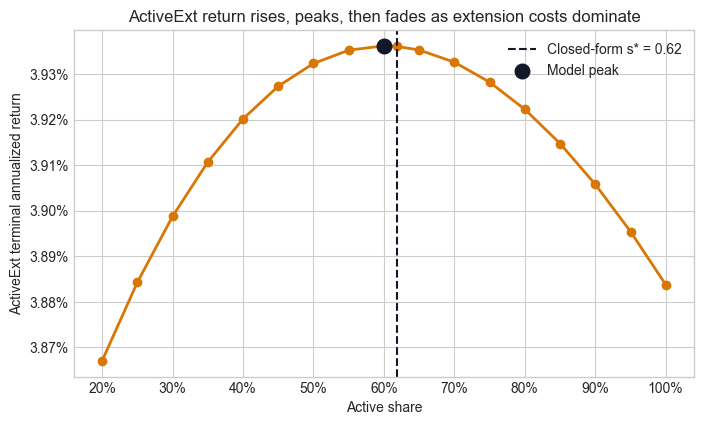

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_active_share_curve.png')

In [10]:
scenario_data = load_yaml_dict("examples/scenarios/active_extension_diminishing_returns.yml")
mu = scenario_data["mu_E_annual"] / 12
c = scenario_data["active_ext_cost_per_share"]
kappa = scenario_data["active_share_tc_decay"]
s_star = (math.sqrt(mu / c) - 1) / kappa
print(f"Closed-form s*: {s_star:.2f}")

shares = np.arange(
    scenario_data["active_share_min_pct"],
    scenario_data["active_share_max_pct"] + scenario_data["active_share_step_pct"],
    scenario_data["active_share_step_pct"],
) / 100
shares = np.array(sorted(set(np.round(np.append(shares, s_star), 4))))

rows = []
for s in shares:
    data = copy.deepcopy(scenario_data)
    data["active_share"] = float(s)
    cfg_s = load_config(data)
    art_s = run_single(cfg_s, idx, RunOptions(seed=42))
    active_row = art_s.summary.loc[art_s.summary["Agent"] == "ActiveExt"].iloc[0]
    rows.append({"active_share": s, "ActiveExt_terminal_AnnReturn": active_row["terminal_AnnReturn"]})

active_curve = pd.DataFrame(rows)
peak = active_curve.loc[active_curve["ActiveExt_terminal_AnnReturn"].idxmax()]
print(f"Model-output peak in grid: active_share={peak.active_share:.2f}, return={peak.ActiveExt_terminal_AnnReturn:.3%}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(active_curve["active_share"], active_curve["ActiveExt_terminal_AnnReturn"], marker="o", color="#d97706", linewidth=2)
ax.axvline(s_star, color="#111827", linestyle="--", linewidth=1.5, label=f"Closed-form s* = {s_star:.2f}")
ax.scatter([peak.active_share], [peak.ActiveExt_terminal_AnnReturn], s=110, color="#111827", zorder=3, label="Model peak")
ax.set_title("ActiveExt return rises, peaks, then fades as extension costs dominate")
ax.set_xlabel("Active share")
ax.set_ylabel("ActiveExt terminal annualized return")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
ax.legend(frameon=False)
savefig(fig, "fig_active_share_curve.png")

**Comprehension Q**

1. If \(\kappa=0\), what is \(\mathrm{TC}(s)\), and what does the alpha formula reduce to?

<details><summary>Answer</summary>
\(\mathrm{TC}(s)=1\), so \(\alpha_{\text{gross}}=s\mu\). That is the old linear model with no diminishing returns.
</details>

2. Two managers have the same \(\mu/\sigma\), but manager A has higher \(\kappa\). Who should run a smaller active share, and why?

<details><summary>Answer</summary>
Manager A. Higher \(\kappa\) means the transfer coefficient decays faster, so the optimum active share is smaller.
</details>

### 3h. Fundamental law of active management

Plain-English idea: the transfer coefficient in 3g is not arbitrary decoration. It is the part of the fundamental law that asks how efficiently forecast skill becomes implemented active risk.

**The equation**

\[
\mathrm{IR}=\mathrm{IC}\sqrt{\mathrm{BR}}\mathrm{TC},\qquad
\alpha=\mathrm{IR}\cdot\sigma_{\text{active}}.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(\mathrm{IR}\) | information ratio | active return per unit active risk |
| \(\mathrm{IC}\) | information coefficient, or forecast skill | correlation/unitless |
| \(\mathrm{BR}\) | breadth, number of independent bets | count |
| \(\mathrm{TC}\) | transfer coefficient, implementation efficiency | unitless |
| \(\alpha\) | expected active return | annual return |
| \(\sigma_{\text{active}}\) | active risk / tracking error budget | annual volatility |

**How the symbols work together (the idea)**

Skill enters linearly through \(\mathrm{IC}\). Breadth enters through a square root because independent bets diversify active noise, but with diminishing scale: 100 independent bets are not 100 times as valuable as one; they are 10 times in this structure. \(\mathrm{TC}\) multiplies the whole skill-breadth engine by implementation efficiency. Then \(\alpha=\mathrm{IR}\sigma_{\text{active}}\) converts a risk-adjusted skill measure into expected active return by applying the active-risk budget.

Behavior to notice: if any of IC, breadth, or TC is zero, IR is zero. Doubling IC doubles IR. Quadrupling breadth doubles IR. In 3g, \(\kappa\) makes TC fall as active share rises, so a larger active bet can have a lower realized IR even if raw manager skill is unchanged.

IR = 0.35; expected active return = 2.10%


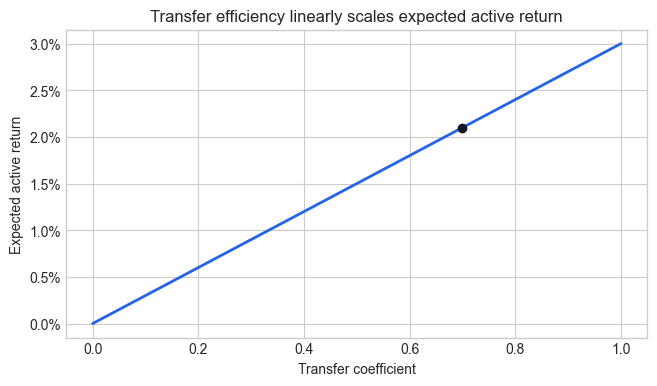

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3h_fundamental_law.png')

In [11]:
IC, BR, TC, sigma_active = 0.05, 100, 0.70, 0.06
IR = IC * math.sqrt(BR) * TC
alpha = IR * sigma_active
print(f"IR = {IR:.2f}; expected active return = {alpha:.2%}")

tc_grid = np.linspace(0, 1, 50)
alpha_grid = IC * np.sqrt(BR) * tc_grid * sigma_active
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tc_grid, alpha_grid, color="#2563eb", linewidth=2)
ax.scatter([TC], [alpha], color="#111827", zorder=3)
ax.set_title("Transfer efficiency linearly scales expected active return")
ax.set_xlabel("Transfer coefficient")
ax.set_ylabel("Expected active return")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
savefig(fig, "fig_3h_fundamental_law.png")

**Comprehension Q**

1. Why does breadth sit under a square root?

<details><summary>Answer</summary>
Independent bets diversify active noise. The law gives diversification a diminishing-return shape: four times the breadth gives about two times the IR contribution.
</details>

2. How does 3g connect to this equation?

<details><summary>Answer</summary>
In 3g, active share \(s\) lowers TC through \(1/(1+\kappa s)\). That directly lowers IR in the fundamental law as the active bet grows.
</details>

### 3i. Margin requirement

Plain-English idea: internal beta backing consumes capital. The simple proxy sizes that capital as a volatility reference times a stress multiple times total capital.

**The equation**

\[
M=\sigma_{\text{ref}}\cdot k\cdot C.
\]

**Symbol table**

| Symbol | Meaning | Units |
|---|---|---|
| \(M\) | margin requirement | dollars or mm dollars |
| \(\sigma_{\text{ref}}\) | reference monthly volatility | monthly volatility |
| \(k\) | volatility multiple / stress multiple | unitless |
| \(C\) | total fund capital | dollars or mm dollars |

**How the symbols work together (the idea)**

The equation is a product because each term scales the same capital reserve from a different angle. \(C\) sets the base dollars. \(\sigma_{\text{ref}}\) converts the reserve into volatility-sized dollars. \(k\) says how many volatility units to hold. There is no offsetting term: higher capital, higher reference volatility, or a higher multiple all raise the requirement.

Behavior to notice: \(M\) is linear in every input. If volatility goes to zero, this proxy says margin goes to zero. If the stress multiple doubles, required margin doubles. That linearity is useful for transparency but it is a proxy, not a broker margin schedule unless the schedule model is explicitly used.

Margin requirement: 9.0mm


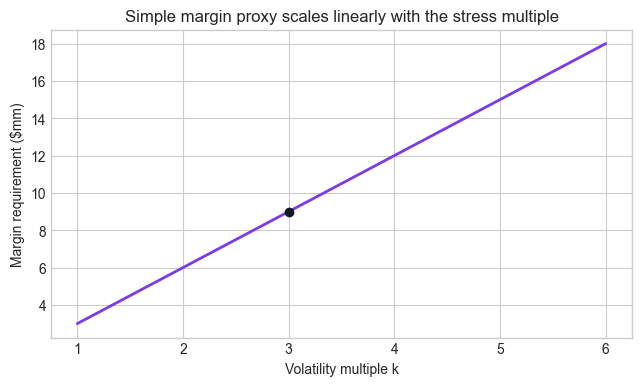

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3i_margin.png')

In [12]:
from pa_core.validators import calculate_margin_requirement

sigma_ref, k, capital = 0.01, 3.0, 300.0
margin = calculate_margin_requirement(sigma_ref, k, capital)
print(f"Margin requirement: {margin:.1f}mm")

multiples = np.linspace(1, 6, 50)
margins = [calculate_margin_requirement(sigma_ref, m, capital) for m in multiples]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(multiples, margins, color="#7c3aed", linewidth=2)
ax.scatter([k], [margin], color="#111827", zorder=3)
ax.set_title("Simple margin proxy scales linearly with the stress multiple")
ax.set_xlabel("Volatility multiple k")
ax.set_ylabel("Margin requirement ($mm)")
savefig(fig, "fig_3i_margin.png")

**Comprehension Q**

1. Which term should you change to represent a stricter broker/stress assumption in the simple proxy?

<details><summary>Answer</summary>
\(k\), the volatility multiple. Raising it linearly raises the required margin.
</details>

2. What does this proxy fail to capture?

<details><summary>Answer</summary>
Nonlinear or term-specific broker rules, concentration add-ons, liquidity haircuts, and scenario-specific margin schedules unless the schedule model is used.
</details>

### Optional: regimes

A regime model uses a row-stochastic transition matrix:

\[
P_{ij}=\Pr(z_{t+1}=j\mid z_t=i),\qquad \sum_j P_{ij}=1.
\]

Each row is a probability distribution for the next state. Per-regime volatilities and correlations can change the return draw shape when `run_single` is used. Current sweeps do not honor regimes, so regime conclusions should not be presented from sweep output without a separate check.

Row sums: [1. 1.]


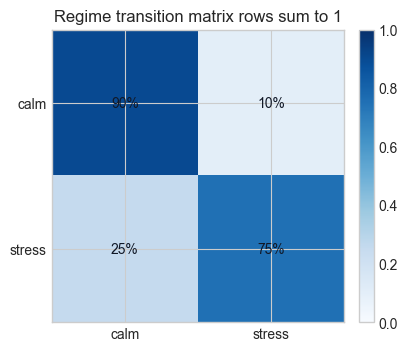

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_3j_regime_matrix.png')

In [13]:
P = np.array([[0.90, 0.10], [0.25, 0.75]])
print("Row sums:", P.sum(axis=1))
fig, ax = plt.subplots(figsize=(4.8, 3.8))
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1], labels=["calm", "stress"])
ax.set_yticks([0, 1], labels=["calm", "stress"])
ax.set_title("Regime transition matrix rows sum to 1")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{P[i, j]:.0%}", ha="center", va="center", color="#111827")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig(fig, "fig_3j_regime_matrix.png")

## 4. What a user can do with the tool

The normal workflow is:

1. Use the dashboard wizard to choose analysis mode, capital allocations, alpha assumptions, risk settings, financing settings, and optional regimes.
2. Run a scenario from the wizard or from the CLI with `pa run --config ... --index ...`.
3. Inspect the Results page for summary metrics, distributions, sleeve comparisons, and run-to-run comparisons.
4. Use scenario-grid sweeps for `returns`, `capital`, `alpha_shares`, and `vol_mult`.
5. Use sensitivity and sleeve optimization to ask which input matters most and which capital allocation satisfies constraints.
6. Export board-pack artifacts when the question needs a shareable summary rather than an interactive exploration.

The next charts are deliberately "good versions" of the audit-sensitive visuals: the risk-return scatter has a legend, sleeve colors, and explicit Base/Total emphasis; the fan chart shows the distribution of Total compounded paths rather than a single path.

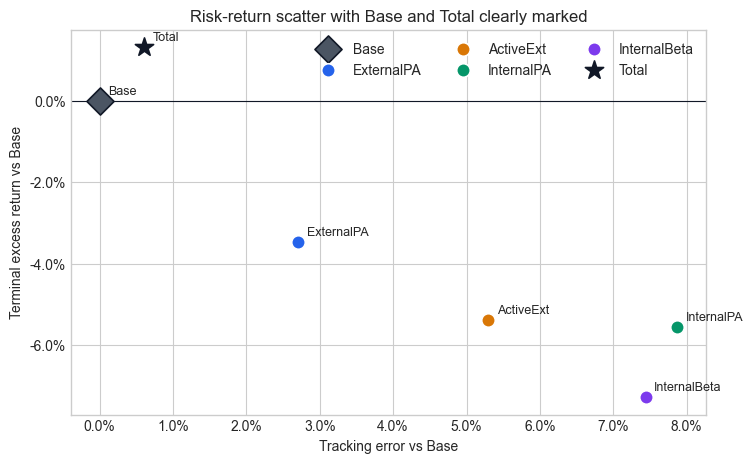

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_risk_return_scatter.png')

In [14]:
plot_summ = summ.copy()
plot_summ["plot_TE"] = plot_summ["monthly_TE"].fillna(0.0)

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for _, row in plot_summ.iterrows():
    agent = row["Agent"]
    marker = "*" if agent == "Total" else ("D" if agent == "Base" else "o")
    size = 190 if agent in {"Total", "Base"} else 95
    edge = "#111827" if agent in {"Total", "Base"} else "white"
    ax.scatter(
        row["plot_TE"],
        row["terminal_ExcessReturn"],
        s=size,
        marker=marker,
        color=COLORS.get(agent, "#6b7280"),
        edgecolor=edge,
        linewidth=1.2,
        label=agent,
        zorder=3 if agent in {"Total", "Base"} else 2,
    )
    ax.annotate(agent, (row["plot_TE"], row["terminal_ExcessReturn"]), xytext=(6, 5), textcoords="offset points", fontsize=9)

ax.axhline(0, color="#111827", linewidth=0.8)
ax.set_title("Risk-return scatter with Base and Total clearly marked")
ax.set_xlabel("Tracking error vs Base")
ax.set_ylabel("Terminal excess return vs Base")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.1%}")
ax.legend(frameon=False, ncol=3, loc="best")
savefig(fig, "fig_risk_return_scatter.png")

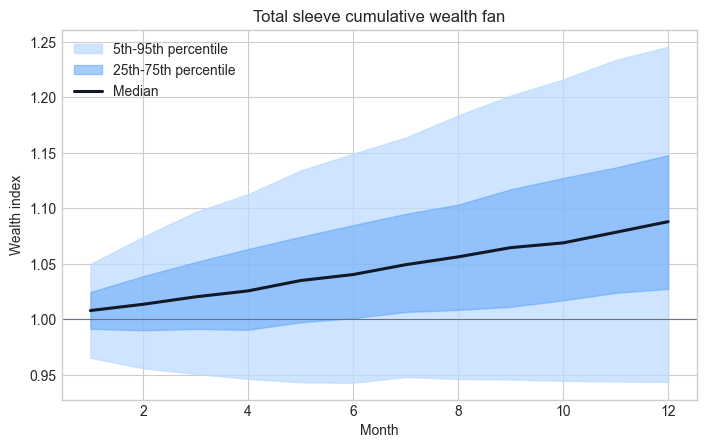

PosixPath('/Users/teacher/.codex/orchestrator/worktrees/stranske__Portable-Alpha-Extension-Model__1928__opener/docs/tutorial/figs/fig_total_fan_chart.png')

In [15]:
wealth = np.cumprod(1 + total, axis=1)
months = np.arange(1, wealth.shape[1] + 1)
p05, p25, p50, p75, p95 = np.percentile(wealth, [5, 25, 50, 75, 95], axis=0)

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.fill_between(months, p05, p95, color="#bfdbfe", alpha=0.75, label="5th-95th percentile")
ax.fill_between(months, p25, p75, color="#60a5fa", alpha=0.55, label="25th-75th percentile")
ax.plot(months, p50, color="#111827", linewidth=2.2, label="Median")
ax.axhline(1.0, color="#6b7280", linewidth=0.8)
ax.set_title("Total sleeve cumulative wealth fan")
ax.set_xlabel("Month")
ax.set_ylabel("Wealth index")
ax.legend(frameon=False)
savefig(fig, "fig_total_fan_chart.png")

## 5. Limitations and how it would be unwise to use this

This chapter is core to the tutorial. The model is useful for disciplined scenario thinking, but it is not an oracle.

| Limitation | Why it matters | Unwise use |
|---|---|---|
| Gross-of-fees | No fee layer means external manager fees, borrow fees beyond configured costs, implementation drag, taxes, and governance costs can be missing. | Presenting model alpha as net value added without fee and implementation adjustments. |
| `Total` excludes `Base` | `Total` is overlay contribution, not benchmark-plus-overlay wealth. A Base-only run shows `Total = 0`. | Treating `Total` as the whole fund return without explaining the convention. |
| Financing `broadcast` default | One financing path is reused across scenarios, which understates financing dispersion and can make tails look cleaner. | Making tail-risk claims from broadcast financing when financing uncertainty is material. |
| Regimes ignored in sweeps | `run_single` honors regimes, but sweeps do not. | Using sweep heatmaps to claim regime-aware optimal allocations. |
| Active share capacity is assumed | PR #1927 adds transfer-coefficient decay, but \(\kappa\) and cost are assumptions, not estimated capacity. | Saying the model "proves" the right active share without calibrating \(\kappa\), costs, borrow, and manager skill decay. |
| I.i.d. monthly draws | The core draw process does not model volatility clustering or serial dependence. | Using one-year Monte Carlo tails as if they captured crisis dynamics or path-dependent liquidity pressure. |
| Inputs are assumptions | The notebook uses configured means, volatilities, correlations, and costs; it does not validate them against a historical backtest. | Treating the output as empirical evidence that a manager or structure will work. |
| No Monte Carlo standard error on CVaR | Tail estimates can look more precise than they are, especially with small simulation counts. | Comparing two CVaR numbers that differ by a few basis points as if the ranking is stable. |

Questions to ask before presenting to colleagues:

- Are the alpha means net of fees, capacity, turnover, borrow, and implementation?
- Are financing assumptions per-path when tail dispersion matters?
- Is `Total` being described as overlay contribution rather than full-fund return?
- Has \(\kappa\) been calibrated from realized manager IR at different active-risk levels?
- Are regimes, correlations, and tail assumptions aligned with the story being told?
- How large is Monte Carlo noise around the tail metric being used for the decision?

## 6. Answer key

- 3a Q1: \(s=0\) removes \((ws)r_E\); beta financing can remain. Q2: `Base` is excluded because it is the benchmark comparator, while `Total` is overlay contribution.
- 3b Q1: covariance divides by 12 because it is a second moment; standard deviation divides by \(\sqrt{12}\). Q2: geometric conversion matters more when means are large or compounding precision matters.
- 3c Q1: the random chi-square denominator creates fat tails. Q2: the t-copula increases joint tail dependence.
- 3d Q1: covariance needs the product of both volatilities, then correlation scales that product. Q2: \(\delta=1\) means full weight on the shrinkage target.
- 3e Q1: subtracting the benchmark makes TE active risk. Q2: pooling path-month draws is not the same operation as averaging per-path standard deviations.
- 3f Q1: the minus sign converts a negative return quantile into a positive loss. Q2: terminal shortfall compounds a full path; monthly breach counts individual months.
- 3g Q1: if \(\kappa=0\), \(\mathrm{TC}=1\) and alpha is \(s\mu\). Q2: the higher-\(\kappa\) manager should run smaller active share because TC decays faster.
- 3h Q1: breadth is under a square root because diversification benefits scale with the square root of independent bets. Q2: 3g makes TC decline as active share rises, lowering IR.
- 3i Q1: change \(k\) for a stricter stress multiple. Q2: the simple proxy misses nonlinear broker rules, concentration, liquidity, and schedule effects.